<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet6%20Regresi/Praktikum%201%20(JS6R).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Langkah 1 : Persiapan Data

In [1]:
# import package
import numpy as np
import pandas as pd

#Langkah 2 : Import Library

In [2]:
# baca data dari file CSV
data = pd.read_csv('dataset.csv')

#Langkah 3 : Baca Data

In [3]:
# baca data dari file CSV
data = pd.read_csv('dataset.csv')

#Langkah 4 : Pemahaman Terhadap Data

In [4]:
# melihat beberapa data awal
data.head()

# mengecek ukuran data
data.shape

# informasi tentang data
data.info()

# deskripsi data
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


#Langkah 5 : Visualisasi Data

In [7]:
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


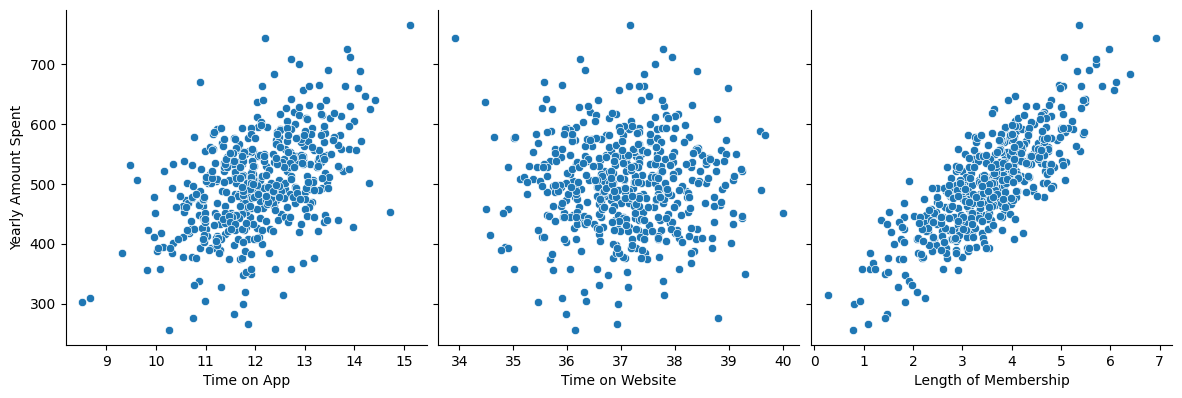

In [9]:
# visualisasi data dengan pairplot
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars='Yearly Amount Spent', size=4, aspect=1, kind='scatter')
plt.show()

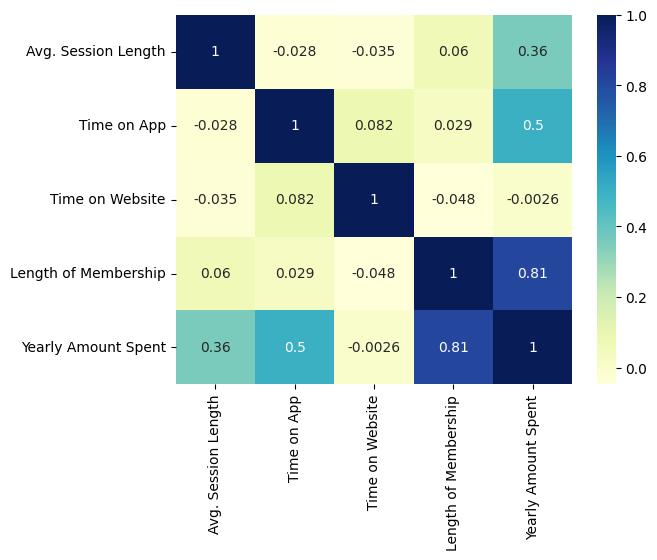

In [11]:
# visualisasi korelasi dengan heatmap
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=True)
plt.show()

#Langkah 6 : Regresi Linierr

In [12]:
# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [13]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [14]:
# Training model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()

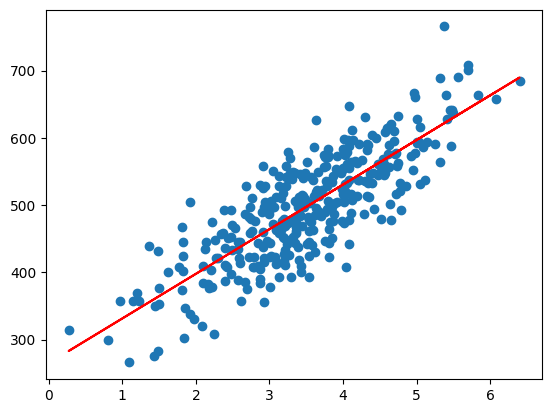

In [15]:
# Visualisasi garis regresi
plt.scatter(X_train, y_train)
plt.plot(X_train, 265.2483 + 66.3015*X_train, 'r')
plt.show()

#Langkah 7 : Analisis Residual

In [16]:
# Prediksi nilai y_value dari data x yang telah dilatih
y_train_pred = lr.predict(X_train_sm)

# Menghitung residual
res = (y_train - y_train_pred)

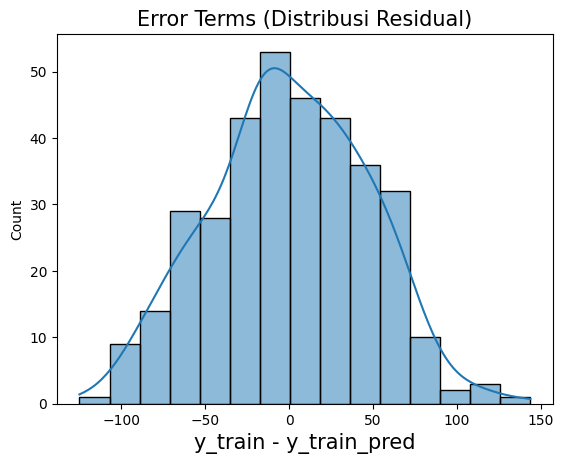

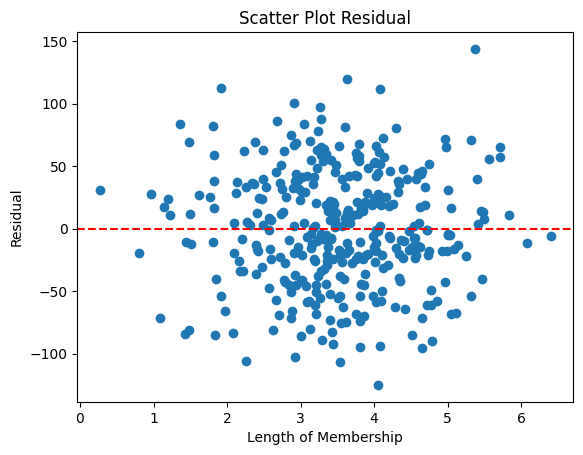

In [26]:
# Histogram residual
fig = plt.figure()
sns.histplot(res, bins=15, kde=True)
plt.title('Error Terms (Distribusi Residual)', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual terhadap X_train
plt.scatter(X_train, res)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Length of Membership')
plt.ylabel('Residual')
plt.title('Scatter Plot Residual')
plt.show()

#Langkah 8 : Prediksi pada Data Uji dan Evaluasi Model

In [18]:
# Prediksi pada data uji
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

In [27]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_test_pred)

print(f"Nilai R-Squared pada Data Uji: {r_squared:.4f}")

Nilai R-Squared pada Data Uji: 0.6119


#Langkah 9 : Visualisasi Hasil

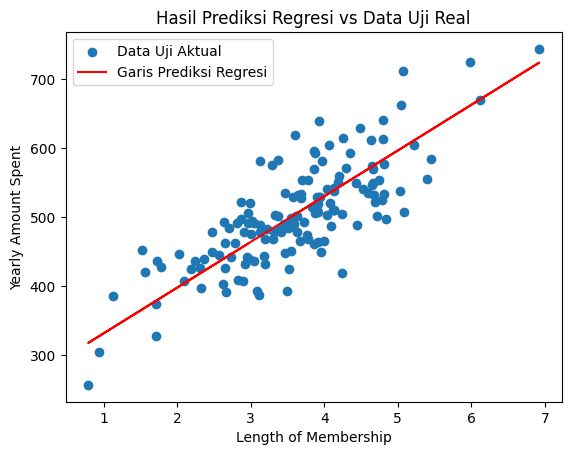

In [28]:
# Visualisasi data uji dan hasil prediksi
plt.scatter(X_test, y_test, label='Data Uji Aktual')
plt.plot(X_test, y_test_pred, 'r', label='Garis Prediksi Regresi')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.title('Hasil Prediksi Regresi vs Data Uji Real')
plt.legend()
plt.show()